# Chapter 8 — Spectral kernels and Bochner

*Companion notebook to **The Learned Kernel**, Ch. 8. Run top to bottom.*

By **Bochner's theorem** a continuous stationary kernel is the Fourier transform of a
finite nonnegative measure on frequencies — the *spectral measure*. So choosing a
stationary geometry **is** choosing a measure on frequencies, and learning the kernel is
learning that measure. We build the **Gaussian spectral-mixture kernel**

$$ k(\tau) = \sum_q w_q\, e^{-2\pi^2 \tau^2 v_q}\, \cos(2\pi \mu_q \tau), \qquad \tau = x - x', $$

the transform of a mixture of Q Gaussians in frequency, and show two things: it recovers
and **extrapolates** a periodic structure a single RBF cannot, and — separately — that the
**readout** (Laplace vs Gaussian), not the spectrum, sets the *roughness* of the function
class.

**The frame** — *what is learned · how scored · what you read off.* We learn a spectral
measure (weights, frequencies, bandwidths). We score it by held-out **query-fold** KRR error
(Ch. 7's leakage-free split). We read off the learned spectral density: broadband near zero
= a smooth trend; a peak away from zero = structure at a definite scale.

## Setup

In [1]:
# On Google Colab (or any fresh env) install the companion package; no-op locally.
try:
    import lkbook  # noqa: F401
except ModuleNotFoundError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
        "learned-kernel[notebooks] @ git+https://github.com/asudjianto-xml/Learned-Kernel.git"],
        check=True)

In [2]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lkbook import set_style
from lkbook.chapters import ch08

set_style()

## 8.1  The readout sets the roughness

The smoothness of a stationary kernel is read from the singularity of its radial profile at
the origin, captured by the intrinsic semimetric d_k² = k(x,x) − 2k(x,x′) + k(x′,x′). The
RBF profile e^(−r²/T²) is analytic (order-2, C^∞); the Laplace e^(−r/T) has a cusp
(order-1, H^((d+1)/2), the Matérn-½ / ReLU-NTK class). On a rough target, with the
bandwidth chosen identically for both, the Laplace fit tracks kinks the RBF rounds off.

In [3]:
r = ch08.roughness_ladder_demo(seed=0)
tbl = pd.DataFrame({"fit RMSE (rough target)": {k: round(v, 3) for k, v in r["rmse"].items()}})
print("same spectrum, same selection — the readout alone moves the fit:")
tbl

same spectrum, same selection — the readout alone moves the fit:


,fit RMSE (rough target)
"RBF (Gaussian, C-inf)",0.071
"Laplace (cusp, H^{(d+1)/2})",0.062


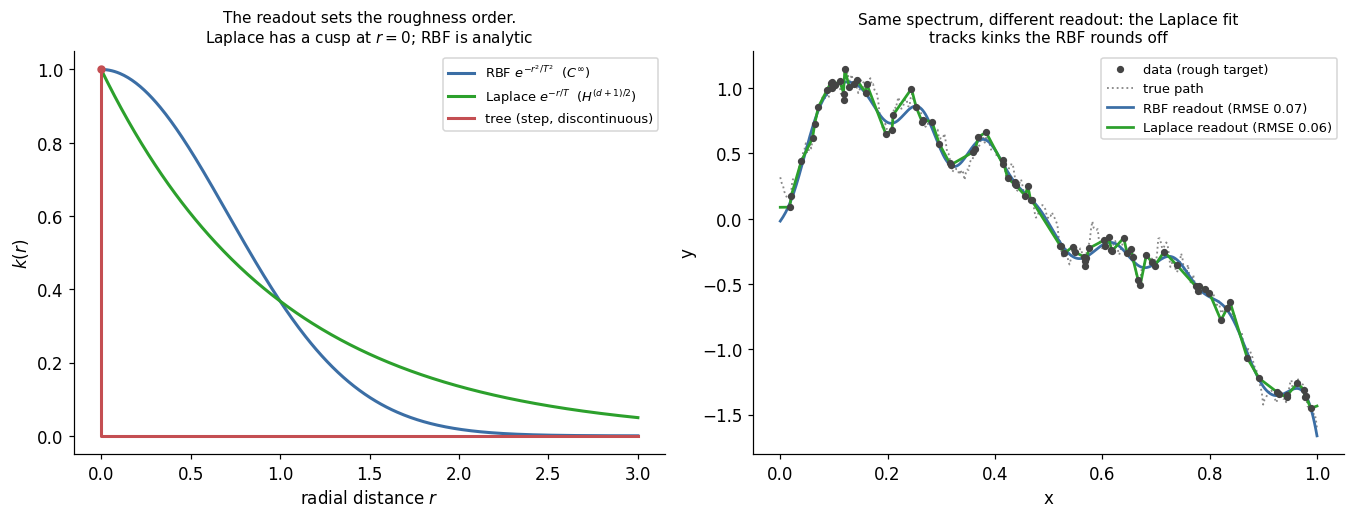

In [4]:
ch08.make_roughness_figure(seed=0)
plt.show()

The Laplace readout admits a class of functions the RBF's RKHS does not contain. No
bandwidth tuning recovers the rough component a C^∞ kernel excludes — the **roughness gate**.

## 8.2  Why one bandwidth is not enough, and Bochner's cure

A single RBF has one knee, at frequency |ω| ~ 1/T. A smooth-plus-periodic target has energy
at two separated scales; one bandwidth cannot serve both. The spectral-mixture kernel places
mass at many frequencies at once — by Bochner, a measure with two peaks. Watch the SM kernel
recover the periodic frequency and **extrapolate** it, where the RBF reverts to the mean.

In [5]:
d = ch08.periodic_extrapolation_demo(seed=0)
print(f"true frequency            {d['true_freq']:.2f}")
print(f"recovered peak frequency  {d['recovered_freq']:.2f}")
tbl = pd.DataFrame({
    "in-hull test RMSE": {"spectral mixture": round(d["sm_test_rmse"], 3),
                          "single RBF": round(d["rbf_test_rmse"], 3)},
    "extrapolation RMSE": {"spectral mixture": round(d["sm_extrap_rmse"], 3),
                           "single RBF": round(d["rbf_extrap_rmse"], 3)},
})
tbl

true frequency            3.00
recovered peak frequency  2.87


,in-hull test RMSE,extrapolation RMSE
spectral mixture,0.026,0.498
single RBF,0.023,1.099


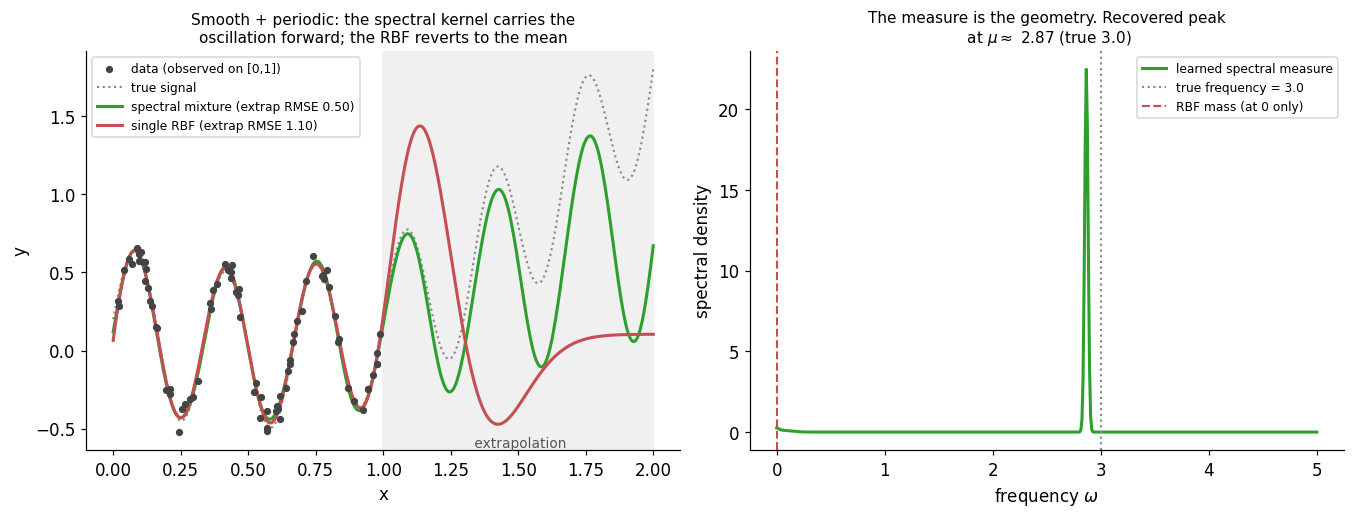

In [6]:
ch08.make_periodic_figure(seed=0)
plt.show()

The SM kernel learned a *frequency*, so it carries the oscillation beyond the data hull. The
RBF learned a *length scale*, so it flattens. The measure is the geometry.

## 8.3  PSD and unit diagonal by construction

The SM kernel is PSD by Bochner (a nonnegative mixture of Gaussians in frequency is a
nonnegative measure) and unit-diagonal when the weights sum to one: k(0) = Σ_q w_q.

In [7]:
k = ch08.SpectralMixtureKernel(w=[0.4, 0.35, 0.25], mu=[0.0, 1.5, 3.0], v=[0.05, 0.1, 0.2])
X = np.sort(np.random.RandomState(0).uniform(0, 1, 80))
K = k.gram(X, X)
print(f"diagonal mean   = {np.diag(K).mean():.4f}  (= Σ w_q = 1)")
print(f"min eigenvalue  = {np.linalg.eigvalsh(K).min():.2e}  (≥ 0 ⟹ PSD)")

diagonal mean   = 1.0000  (= Σ w_q = 1)
min eigenvalue  = -7.33e-15  (≥ 0 ⟹ PSD)


## 8.4  The measure is the geometry, on California

Fit the SM kernel per California feature and read the learned spectral density. Median income
concentrates mass near zero (a smooth trend); latitude puts a peak away from zero (spatial
structure at a scale). You read the geometry straight off the measure.

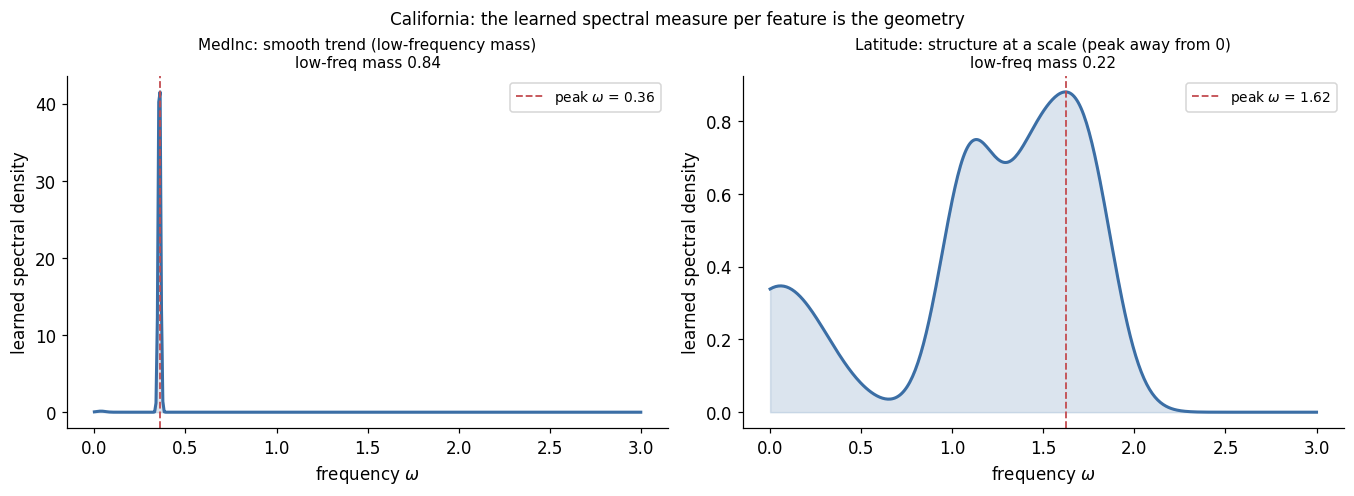

,peak ω,low-freq mass,SM query loss,RBF query loss
MedInc,0.36,0.84,0.689,0.682
Latitude,1.62,0.22,1.124,1.131


In [8]:
fig, info = ch08.make_california_density_figure(seed=0)
plt.show()
pd.DataFrame({f: {"peak ω": round(float(c["omega"][np.argmax(c["density"])]), 2),
                  "low-freq mass": round(c["lowfreq_mass"], 2),
                  "SM query loss": round(c["sm_qloss"], 3),
                  "RBF query loss": round(c["rbf_qloss"], 3)}
              for f, c in info.items()}).T

## 8.5  Density parameterization — continuity is free

Refining the frequency grid is a numerical cost, not a statistical one. A Q-component density
on log-frequency is quadratured by Gauss–Hermite into G atoms; the **trainable** size is the
density's parameters, independent of G. Increase G fourfold — the spectral mass and the mean
frequency the density represents do not move.

In [9]:
rows = {}
for G in (4, 8, 16):
    omega, wts = ch08.density_atoms_gauss_hermite(mu_log=0.0, gamma=0.4, G=G)
    rows[f"G = {G}"] = {"# atoms": len(omega), "mass sum": round(float(wts.sum()), 4),
                        "mean frequency": round(float((omega * wts).sum()), 3),
                        "# trainable": 2}
pd.DataFrame(rows).T

,# atoms,mass sum,mean frequency,# trainable
G = 4,4.0,1.0,1.083,2.0
G = 8,8.0,1.0,1.083,2.0
G = 16,16.0,1.0,1.083,2.0


## 8.6  Interactive: move the spectral measure

Move the periodic frequency μ and the bandwidth (envelope variance v) and watch the kernel
profile and the fitted curve respond. A frequency away from zero is an oscillation; a small v
is a wide envelope (long-range carrier). This is the geometry you are learning.

In [10]:
from ipywidgets import interact, FloatSlider

_X, _y, _f = ch08.smooth_plus_periodic(n=80, freq=3.0, seed=0)
_Xg = np.linspace(0, 1.6, 300)


def explore(mu=3.0, v=0.04, w_periodic=0.6):
    # a two-component measure: a smooth DC bump + a periodic carrier at frequency mu
    k = ch08.SpectralMixtureKernel(w=[1 - w_periodic, w_periodic], mu=[0.0, mu], v=[0.01, v])
    alpha = np.linalg.solve(k.gram(_X, _X) + 1e-3 * np.eye(len(_X)), _y - _y.mean())
    pred = k.gram(_Xg, _X) @ alpha + _y.mean()
    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.0), constrained_layout=True)
    tau = np.linspace(-1, 1, 400)
    axes[0].plot(tau, k.profile(tau), color="#2ca02c")
    axes[0].set_title("kernel profile k(τ)"); axes[0].set_xlabel("lag τ")
    axes[1].scatter(_X, _y, s=12, c="#444", zorder=3)
    axes[1].plot(_Xg, pred, color="#2ca02c", lw=2, label="SM fit")
    axes[1].axvspan(1.0, 1.6, color="#f0f0f0", zorder=0)
    axes[1].set_title(f"fit + extrapolation (μ={mu:.1f}, v={v:.3f})")
    axes[1].set_xlabel("x"); axes[1].legend(fontsize=8)
    plt.show()


interact(explore,
         mu=FloatSlider(min=0.5, max=5.0, step=0.25, value=3.0, description="frequency μ"),
         v=FloatSlider(min=0.005, max=0.2, step=0.005, value=0.04, description="bandwidth v"),
         w_periodic=FloatSlider(min=0.0, max=1.0, step=0.1, value=0.6, description="periodic w"));

interactive(children=(FloatSlider(value=3.0, description='frequency μ', max=5.0, min=0.5, step=0.25), FloatSli…

## Exercises

Fill in each `# TODO`; the solution is one click away.

**(easy)** Confirm the SM kernel's unit diagonal and PSD-ness for your own measure.

In [11]:
# TODO: build a SpectralMixtureKernel with weights summing to 1 and check diag + min eigenvalue
diag_mean = min_eig = None
print(diag_mean, min_eig)

None None


<details><summary>Solution</summary>

```python
k = ch08.SpectralMixtureKernel(w=[0.5, 0.5], mu=[0.0, 2.0], v=[0.03, 0.1])
K = k.gram(X, X)
diag_mean = float(np.diag(K).mean())               # 1.000  (= sum of weights)
min_eig = float(np.linalg.eigvalsh(K).min())       # >= 0   (PSD by Bochner)
print(diag_mean, min_eig)
```
k(0) = Σ_q w_q, so unit weights give a unit diagonal; the kernel is a nonnegative mixture of
(cosine × Gaussian-envelope) terms, each a valid spectral measure, so the sum is PSD.
</details>

**(⋆)** Show the RBF is the single-Gaussian-at-zero special case of Bochner: a one-component
SM kernel with μ = 0 and v = 1/(4π²ℓ²) equals the RBF of length scale ℓ.

In [12]:
# TODO: pick ell, build the matching SM kernel, and compare K_sm to ch08.rbf_kernel
ell = 0.3
match = None  # max |K_sm - K_rbf|

<details><summary>Solution</summary>

```python
ell = 0.3
v0 = 1.0 / (4.0 * np.pi**2 * ell**2)
sm = ch08.SpectralMixtureKernel([1.0], [0.0], [v0])
K_sm = sm.gram(X, X); K_rbf = ch08.rbf_kernel(X, X, ell)
match = float(np.max(np.abs(K_sm - K_rbf)))        # ~ 1e-16
print(match)
```
The Fourier transform of a single Gaussian centered at ω = 0 is a Gaussian in τ — the RBF.
Moving the bump away from 0 is exactly what adds the periodic component the RBF lacks.
</details>

---
*Companion to Chapter 8 of **The Learned Kernel**. The spectral-mixture kernel, the roughness
ladder and the recovery beat come from `lkbook.chapters.ch08` — the same code the book's
figures are generated from. Related Substack reading: "A Smooth Alternative to the Boosted
Tree."*